# Visualización un solo curso

--- 🎨 Generando t-SNE Multirrelacional para MA1002 ---
Alumnos a visualizar: 742
Ejecutando t-SNE sobre matriz de forma: (742, 13)...
✅ Imagen guardada en: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\tsne_interaction_MA1002_rdim13.png


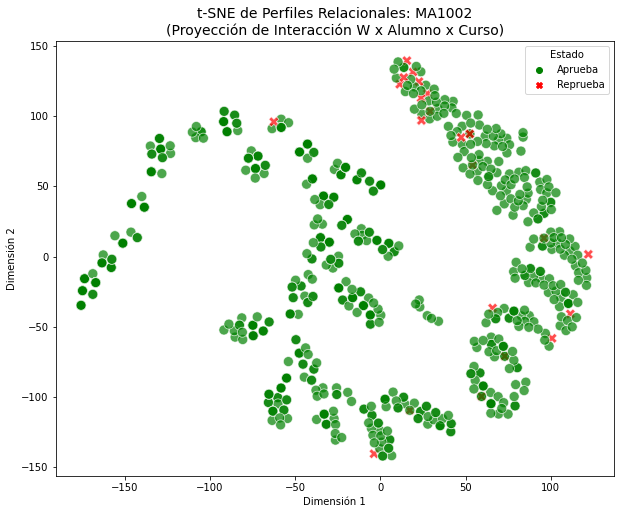

In [2]:
# -*- coding: utf-8 -*-
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from types import SimpleNamespace

# =====================================
# CONFIGURACIÓN
# =====================================
RDIM = 13  # El modelo "ganador"
CURSO_OBJETIVO = 'MA1002' # Curso para el cual proyectaremos (Cálculo II)

# Rutas (Ajustadas a tu estructura S1->S2 Balanceada)
BASE_PATH = r"C:\Users\56946\TuckER\mis_scripts\dataframes_por_semestre"
RESULTS_BASE = r"C:\Users\56946\TuckER\results"
TUCKER_DATA_DIR = r"C:\Users\56946\TuckER\data\dataset_20192_fundamentales"
PREDICTOR_BASE = r"C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados"

# Nombres de archivos
RUN_PREFIX   = f"Experimento_warm_start_rdim{RDIM}_1000epochs_earlystopping_2019patience400_balanceado"
PREDICTOR_NAME = f"best_predictor_dim4_rdim{RDIM}_2019_balanceado.pt"

# Datos 2020 (Cohorte de validación)
CSV_HISTORIA = os.path.join(BASE_PATH, "df_20201.csv")
CSV_TARGET   = os.path.join(BASE_PATH, "df_20202.csv")

CURSOS_PRIMER = ['MA1101','MA1001','FI1000','BT1211']
DEVICE = "cpu"

# =====================================
# FUNCIONES
# =====================================

def get_vocab_manual(data_dir):
    entities, relations = set(), set()
    nombres = ['train.txt', 'train_balanceado.txt', 'valid.txt', 'test.txt']
    for part in nombres:
        path = os.path.join(data_dir, part)
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    if not line.strip(): continue
                    h, r, t = line.strip().split()
                    entities.add(h.strip().upper()); entities.add(t.strip().upper()); relations.add(r.strip())
    entities = sorted(list(entities))
    relations = sorted(list(relations))
    relations_full = sorted(list(set(relations + [r + "_reverse" for r in relations])))
    return SimpleNamespace(entities=entities, entity_idxs={e: i for i, e in enumerate(entities)})

def load_tucker_weights(path, device="cpu"):
    sd = torch.load(path, map_location=device)
    if "model_state_dict" in sd: sd = sd["model_state_dict"]
    return sd["E.weight"].to(device), sd["W"].to(device)

class EmbeddingPredictor(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, output_size)
        )
    def forward(self, x): return self.network(x)

def limpiar_nota(nota_str, estado):
    if isinstance(estado, str) and "Reprobado" in estado: return 1.0
    try: return float(str(nota_str).replace(",", ".")) if not pd.isna(nota_str) else 0.0
    except: return 0.0

def precalcular_vectores_sem1(alumnos_ids, df_historia, idx_primer):
    vectores_np = {aid: np.zeros(4, dtype=np.float32) for aid in alumnos_ids}
    df_f = df_historia[df_historia["ID"].isin(alumnos_ids)]
    for _, row in df_f.iterrows():
        if row["CURSO"] in idx_primer:
            vectores_np[row["ID"]][idx_primer[row["CURSO"]]] = limpiar_nota(row["NOTA"], row["ESTADO_CURSO"])
    return {aid: torch.tensor(vec/7.0).view(1, -1) for aid, vec in vectores_np.items()}

# =====================================
# LÓGICA DE PROYECCIÓN Y T-SNE
# =====================================

def calcular_perfil_relacional(W, e_s, e_o):
    """
    Calcula v = W x_2 e_s x_3 e_o
    W: [d_r, d_e, d_e]
    e_s: [d_e] (Estudiante)
    e_o: [d_e] (Curso)
    Retorna: [d_r] (Vector en el espacio de relaciones)
    """
    # 1. Contraer W con Estudiante (Modo 2, índice 1 en python 0-based)
    # W shape: (dr, de, de). e_s shape: (de)
    # tensor_dot sumará sobre la dimensión 1 de W y la 0 de e_s
    # Resultado shape: (dr, de)
    temp = torch.tensordot(W, e_s, dims=([1], [0]))
    
    # 2. Contraer resultado con Curso (Modo 3, índice 1 en el temp)
    # temp shape: (dr, de). e_o shape: (de)
    # Resultado shape: (dr)
    v_perfil = torch.tensordot(temp, e_o, dims=([1], [0]))
    
    return v_perfil.cpu().numpy()

# ... (Todo el código anterior de importaciones y funciones se mantiene igual) ...

def main():
    print(f"--- 🎨 Generando t-SNE Multirrelacional para {CURSO_OBJETIVO} ---")
    
    # 1. Cargar Modelos (Igual que antes)
    vocab = get_vocab_manual(TUCKER_DATA_DIR)
    tucker_path = os.path.join(RESULTS_BASE, RUN_PREFIX.format(rdim=RDIM), "best_model.pt")
    pred_path = os.path.join(PREDICTOR_BASE, PREDICTOR_NAME.format(rdim=RDIM))
    
    if not os.path.exists(tucker_path) or not os.path.exists(pred_path):
        print("❌ Archivos no encontrados.")
        return

    E, W = load_tucker_weights(tucker_path, DEVICE)
    d_e = E.shape[1]
    
    predictor = EmbeddingPredictor(4, d_e).to(DEVICE)
    predictor.load_state_dict(torch.load(pred_path, map_location=DEVICE))
    predictor.eval()
    
    if CURSO_OBJETIVO not in vocab.entity_idxs:
        print(f"❌ El curso {CURSO_OBJETIVO} no está en el vocabulario.")
        return
    
    idx_curso = vocab.entity_idxs[CURSO_OBJETIVO]
    e_curso = E[idx_curso] 

    # 2. Datos 2020
    df_hist = pd.read_csv(CSV_HISTORIA, sep=';')
    df_tgt  = pd.read_csv(CSV_TARGET, sep=';')
    
    for df in [df_hist, df_tgt]:
        df['ID'] = df['ID'].astype(str).str.strip().str.upper()
        df['CURSO'] = df['CURSO'].astype(str).str.strip().str.upper()

    df_fund = df_hist[df_hist["CURSO"].isin(CURSOS_PRIMER)]
    conteo = df_fund.groupby("ID")["CURSO"].nunique()
    alumnos_validos = set(conteo[conteo == 4].index)
    
    df_curso = df_tgt[df_tgt['CURSO'] == CURSO_OBJETIVO].copy()
    df_curso = df_curso[df_curso['ID'].isin(alumnos_validos)]
    print(f"Alumnos a visualizar: {len(df_curso)}")
    
    idx_primer = {c: i for i, c in enumerate(CURSOS_PRIMER)}
    vectores_x = precalcular_vectores_sem1(alumnos_validos, df_hist, idx_primer)
    
    # 3. Generar Vectores de Perfil
    vectores_tsne = []
    etiquetas = []
    notas = []
    
    with torch.no_grad():
        for _, row in df_curso.iterrows():
            aid = row['ID']
            if aid not in vectores_x: continue
            
            x_vec = vectores_x[aid].to(DEVICE)
            e_alumno = predictor(x_vec).squeeze(0)
            
            v_perfil = calcular_perfil_relacional(W, e_alumno, e_curso)
            vectores_tsne.append(v_perfil)
            
            estado = str(row['ESTADO_CURSO'])
            nota_val = row['NOTA']
            
            label = "Aprueba"
            if "Reprobado" in estado: label = "Reprueba"
            elif "Aprobado" not in estado:
                try:
                    if float(str(nota_val).replace(",", ".")) < 4.0: label = "Reprueba"
                except: pass
            
            etiquetas.append(label)
            try: notas.append(float(str(nota_val).replace(",", ".")))
            except: notas.append(0.0)

    # 4. t-SNE (CORREGIDO)
    # Convertimos explícitamente a float32 para evitar problemas de tipos
    X = np.array(vectores_tsne, dtype=np.float32)
    print(f"Ejecutando t-SNE sobre matriz de forma: {X.shape}...")
    
    perp = min(30, len(X)-1) if len(X) > 1 else 1
    
    # ⚠️ CAMBIO: learning_rate=200.0 en lugar de 'auto'
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp, init='pca', learning_rate=200.0)
    X_embedded = tsne.fit_transform(X)
    
    # 5. Plot
    df_plot = pd.DataFrame({
        'x': X_embedded[:, 0],
        'y': X_embedded[:, 1],
        'Estado': etiquetas,
        'Nota': notas
    })
    
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=df_plot, x='x', y='y', 
        hue='Estado', style='Estado', 
        palette={'Aprueba': 'green', 'Reprueba': 'red'},
        s=100, alpha=0.7
    )
    plt.title(f"t-SNE de Perfiles Relacionales: {CURSO_OBJETIVO}\n(Proyección de Interacción W x Alumno x Curso)", fontsize=14)
    plt.xlabel("Dimensión 1")
    plt.ylabel("Dimensión 2")
    
    output_img = os.path.join(PREDICTOR_BASE, f"tsne_interaction_{CURSO_OBJETIVO}_rdim{RDIM}.png")
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ Imagen guardada en: {output_img}")
    # plt.show() # Comentado si corres en entorno sin pantalla

if __name__ == "__main__":
    main()

### un solo curso con notas

### Cálculo del Vector de Perfil Relacional

Para visualizar cómo el modelo *percibe* la interacción entre un alumno específico y un curso, construimos un vector $v_{s,o} \in \mathbb{R}^{d_r}$ en el espacio de las relaciones.

Este vector resulta de contraer el tensor núcleo $\mathcal{W}$ con los embeddings de la entidad sujeto (alumno) y la entidad objeto (curso).

Matemáticamente, la operación es:

$$
v_{s,o} = \mathcal{W} \times_1 e_s \times_3 e_o
$$

Donde:
- $\mathcal{W} \in \mathbb{R}^{d_e \times d_r \times d_e}$ es el tensor núcleo entrenado.
- $e_s \in \mathbb{R}^{d_e}$ es el embedding del alumno (predicho por la red neuronal).
- $e_o \in \mathbb{R}^{d_e}$ es el embedding del curso (aprendido por TuckER).
- $\times_n$ denota el producto tensorial en el modo $n$.

En términos de componentes, el vector resultante $v_{s,o}$ (de dimensión $d_r$) se calcula como:

$$
(v_{s,o})_j = \sum_{i=1}^{d_e} \sum_{k=1}^{d_e} \mathcal{W}_{ijk} \cdot (e_s)_i \cdot (e_o)_k, \quad \text{para } j = 1, \dots, d_r
$$

Este vector $v_{s,o}$ condensa toda la información latente sobre *cómo* se relaciona ese alumno con ese curso, y es lo que usamos como entrada para el t-SNE.

--- 🎨 Generando t-SNE por Nota para MA1002 ---
Alumnos a visualizar: 742
✅ Imagen guardada en: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\tsne_notas_MA1002_rdim13.png


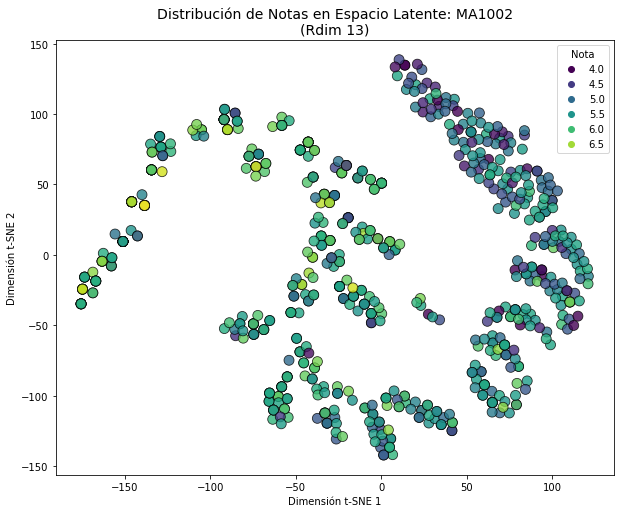

In [1]:
# -*- coding: utf-8 -*-
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from types import SimpleNamespace

# =====================================
# CONFIGURACIÓN
# =====================================
RDIM = 13  
CURSO_OBJETIVO = 'MA1002' 

# Rutas (Ajustadas a tu estructura S1->S2 Balanceada)
BASE_PATH = r"C:\Users\56946\TuckER\mis_scripts\dataframes_por_semestre"
RESULTS_BASE = r"C:\Users\56946\TuckER\results"
TUCKER_DATA_DIR = r"C:\Users\56946\TuckER\data\dataset_20192_fundamentales"
PREDICTOR_BASE = r"C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados"

RUN_PREFIX   = f"Experimento_warm_start_rdim{RDIM}_1000epochs_earlystopping_2019patience400_balanceado"
PREDICTOR_NAME = f"best_predictor_dim4_rdim{RDIM}_2019_balanceado.pt"

CSV_HISTORIA = os.path.join(BASE_PATH, "df_20201.csv")
CSV_TARGET   = os.path.join(BASE_PATH, "df_20202.csv")

CURSOS_PRIMER = ['MA1101','MA1001','FI1000','BT1211']
DEVICE = "cpu"

# =====================================
# FUNCIONES
# =====================================

def get_vocab_manual(data_dir):
    entities, relations = set(), set()
    nombres = ['train.txt', 'train_balanceado.txt', 'valid.txt', 'test.txt']
    for part in nombres:
        path = os.path.join(data_dir, part)
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    if not line.strip(): continue
                    h, r, t = line.strip().split()
                    entities.add(h.strip().upper()); entities.add(t.strip().upper()); relations.add(r.strip())
    entities = sorted(list(entities))
    return SimpleNamespace(entities=entities, entity_idxs={e: i for i, e in enumerate(entities)})

def load_tucker_weights(path, device="cpu"):
    sd = torch.load(path, map_location=device)
    if "model_state_dict" in sd: sd = sd["model_state_dict"]
    return sd["E.weight"].to(device), sd["W"].to(device)

class EmbeddingPredictor(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, output_size)
        )
    def forward(self, x): return self.network(x)

def limpiar_nota(nota_str, estado):
    if isinstance(estado, str) and "Reprobado" in estado: return 1.0
    try: return float(str(nota_str).replace(",", ".")) if not pd.isna(nota_str) else 0.0
    except: return 0.0

def precalcular_vectores_sem1(alumnos_ids, df_historia, idx_primer):
    vectores_np = {aid: np.zeros(4, dtype=np.float32) for aid in alumnos_ids}
    df_f = df_historia[df_historia["ID"].isin(alumnos_ids)]
    for _, row in df_f.iterrows():
        if row["CURSO"] in idx_primer:
            vectores_np[row["ID"]][idx_primer[row["CURSO"]]] = limpiar_nota(row["NOTA"], row["ESTADO_CURSO"])
    return {aid: torch.tensor(vec/7.0).view(1, -1) for aid, vec in vectores_np.items()}

def calcular_perfil_relacional(W, e_s, e_o):
    temp = torch.tensordot(W, e_s, dims=([1], [0]))
    v_perfil = torch.tensordot(temp, e_o, dims=([1], [0]))
    return v_perfil.cpu().numpy()

def main():
    print(f"--- 🎨 Generando t-SNE por Nota para {CURSO_OBJETIVO} ---")
    
    vocab = get_vocab_manual(TUCKER_DATA_DIR)
    tucker_path = os.path.join(RESULTS_BASE, RUN_PREFIX.format(rdim=RDIM), "best_model.pt")
    pred_path = os.path.join(PREDICTOR_BASE, PREDICTOR_NAME.format(rdim=RDIM))
    
    if not os.path.exists(tucker_path) or not os.path.exists(pred_path):
        print("❌ Archivos no encontrados.")
        return

    E, W = load_tucker_weights(tucker_path, DEVICE)
    d_e = E.shape[1]
    
    predictor = EmbeddingPredictor(4, d_e).to(DEVICE)
    predictor.load_state_dict(torch.load(pred_path, map_location=DEVICE))
    predictor.eval()
    
    if CURSO_OBJETIVO not in vocab.entity_idxs:
        print(f"❌ El curso {CURSO_OBJETIVO} no está en el vocabulario.")
        return
    
    idx_curso = vocab.entity_idxs[CURSO_OBJETIVO]
    e_curso = E[idx_curso] 

    # Datos
    df_hist = pd.read_csv(CSV_HISTORIA, sep=';')
    df_tgt  = pd.read_csv(CSV_TARGET, sep=';')
    
    for df in [df_hist, df_tgt]:
        df['ID'] = df['ID'].astype(str).str.strip().str.upper()
        df['CURSO'] = df['CURSO'].astype(str).str.strip().str.upper()

    df_fund = df_hist[df_hist["CURSO"].isin(CURSOS_PRIMER)]
    conteo = df_fund.groupby("ID")["CURSO"].nunique()
    alumnos_validos = set(conteo[conteo == 4].index)
    
    df_curso = df_tgt[df_tgt['CURSO'] == CURSO_OBJETIVO].copy()
    df_curso = df_curso[df_curso['ID'].isin(alumnos_validos)]
    print(f"Alumnos a visualizar: {len(df_curso)}")
    
    idx_primer = {c: i for i, c in enumerate(CURSOS_PRIMER)}
    vectores_x = precalcular_vectores_sem1(alumnos_validos, df_hist, idx_primer)
    
    vectores_tsne = []
    notas = []
    
    with torch.no_grad():
        for _, row in df_curso.iterrows():
            aid = row['ID']
            if aid not in vectores_x: continue
            
            x_vec = vectores_x[aid].to(DEVICE)
            e_alumno = predictor(x_vec).squeeze(0)
            
            v_perfil = calcular_perfil_relacional(W, e_alumno, e_curso)
            vectores_tsne.append(v_perfil)
            
            # Obtener Nota Real (numérica)
            try: 
                nota_float = float(str(row['NOTA']).replace(",", "."))
            except: 
                nota_float = 1.0 # Si no hay nota (ej: Reprobado sin nota), ponemos 1.0
            
            notas.append(nota_float)

    # t-SNE
    X = np.array(vectores_tsne, dtype=np.float32)
    perp = min(30, len(X)-1) if len(X) > 1 else 1
    
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp, init='pca', learning_rate=200.0)
    X_embedded = tsne.fit_transform(X)
    
    # Plot con Colores Continuos
    df_plot = pd.DataFrame({
        'x': X_embedded[:, 0],
        'y': X_embedded[:, 1],
        'Nota': notas
    })
    
    plt.figure(figsize=(10, 8))
    
    # ⚠️ CAMBIO PRINCIPAL: hue='Nota' y palette='viridis' (o 'coolwarm', 'magma')
    scatter = sns.scatterplot(
        data=df_plot, x='x', y='y', 
        hue='Nota', 
        palette='viridis', # Mapa de color: Azul/Morado (Bajo) -> Amarillo (Alto)
        s=100, alpha=0.8,
        edgecolor='k' # Borde negro para resaltar
    )
    
    # Barra de color manual si seaborn no la muestra bien
    # plt.colorbar(scatter.collections[0], label="Nota Final")
    
    plt.title(f"Distribución de Notas en Espacio Latente: {CURSO_OBJETIVO}\n(Rdim {RDIM})", fontsize=14)
    plt.xlabel("Dimensión t-SNE 1")
    plt.ylabel("Dimensión t-SNE 2")
    
    output_img = os.path.join(PREDICTOR_BASE, f"tsne_notas_{CURSO_OBJETIVO}_rdim{RDIM}.png")
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    print(f"✅ Imagen guardada en: {output_img}")

if __name__ == "__main__":
    main()

# todos los cursos_sin notas

In [3]:
# -*- coding: utf-8 -*-
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from types import SimpleNamespace

# =====================================
# CONFIGURACIÓN
# =====================================
RDIM = 13  # Modelo seleccionado

# Rutas
BASE_PATH = r"C:\Users\56946\TuckER\mis_scripts\dataframes_por_semestre"
RESULTS_BASE = r"C:\Users\56946\TuckER\results"
TUCKER_DATA_DIR = r"C:\Users\56946\TuckER\data\dataset_20192_fundamentales"
PREDICTOR_BASE = r"C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados"

# Nombres de archivos
RUN_PREFIX   = f"Experimento_warm_start_rdim{RDIM}_1000epochs_earlystopping_2019patience400_balanceado"
PREDICTOR_NAME = f"best_predictor_dim4_rdim{RDIM}_2019_balanceado.pt"

# Datos 2020
CSV_HISTORIA = os.path.join(BASE_PATH, "df_20201.csv")
CSV_TARGET   = os.path.join(BASE_PATH, "df_20202.csv")

# ⚠️ LISTA COMPLETA DE CURSOS A VISUALIZAR
CURSOS_PRIMER  = ['MA1101','MA1001','FI1000','BT1211']
CURSOS_SEGUNDO = ['MA1002','MA1102','FI1100','CC1002']
CURSOS_A_GRAFICAR = CURSOS_PRIMER + CURSOS_SEGUNDO

DEVICE = "cpu"

# =====================================
# FUNCIONES
# =====================================

def get_vocab_manual(data_dir):
    entities, relations = set(), set()
    nombres = ['train.txt', 'train_balanceado.txt', 'valid.txt', 'test.txt']
    for part in nombres:
        path = os.path.join(data_dir, part)
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    if not line.strip(): continue
                    h, r, t = line.strip().split()
                    entities.add(h.strip().upper()); entities.add(t.strip().upper()); relations.add(r.strip())
    entities = sorted(list(entities))
    return SimpleNamespace(entities=entities, entity_idxs={e: i for i, e in enumerate(entities)})

def load_tucker_weights(path, device="cpu"):
    sd = torch.load(path, map_location=device)
    if "model_state_dict" in sd: sd = sd["model_state_dict"]
    return sd["E.weight"].to(device), sd["W"].to(device)

class EmbeddingPredictor(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, output_size)
        )
    def forward(self, x): return self.network(x)

def limpiar_nota(nota_str, estado):
    if isinstance(estado, str) and "Reprobado" in estado: return 1.0
    try: return float(str(nota_str).replace(",", ".")) if not pd.isna(nota_str) else 0.0
    except: return 0.0

def precalcular_vectores_sem1(alumnos_ids, df_historia, idx_primer):
    vectores_np = {aid: np.zeros(4, dtype=np.float32) for aid in alumnos_ids}
    df_f = df_historia[df_historia["ID"].isin(alumnos_ids)]
    for _, row in df_f.iterrows():
        if row["CURSO"] in idx_primer:
            vectores_np[row["ID"]][idx_primer[row["CURSO"]]] = limpiar_nota(row["NOTA"], row["ESTADO_CURSO"])
    return {aid: torch.tensor(vec/7.0).view(1, -1) for aid, vec in vectores_np.items()}

def calcular_perfil_relacional(W, e_s, e_o):
    # W x_2 e_s x_3 e_o -> Vector de relación
    temp = torch.tensordot(W, e_s, dims=([1], [0]))
    v_perfil = torch.tensordot(temp, e_o, dims=([1], [0]))
    return v_perfil.cpu().numpy()

def main():
    print(f"--- 🎨 Generando t-SNE Masivo (Rdim {RDIM}) ---")
    
    # 1. Cargar Modelos
    vocab = get_vocab_manual(TUCKER_DATA_DIR)
    tucker_path = os.path.join(RESULTS_BASE, RUN_PREFIX.format(rdim=RDIM), "best_model.pt")
    pred_path = os.path.join(PREDICTOR_BASE, PREDICTOR_NAME.format(rdim=RDIM))
    
    if not os.path.exists(tucker_path) or not os.path.exists(pred_path):
        print("❌ Archivos no encontrados.")
        return

    E, W = load_tucker_weights(tucker_path, DEVICE)
    d_e = E.shape[1]
    
    predictor = EmbeddingPredictor(4, d_e).to(DEVICE)
    predictor.load_state_dict(torch.load(pred_path, map_location=DEVICE))
    predictor.eval()

    # 2. Cargar Datos 2020
    print("Cargando DataFrames...")
    df_hist = pd.read_csv(CSV_HISTORIA, sep=';')
    df_tgt  = pd.read_csv(CSV_TARGET, sep=';')
    for df in [df_hist, df_tgt]:
        df['ID'] = df['ID'].astype(str).str.strip().str.upper()
        df['CURSO'] = df['CURSO'].astype(str).str.strip().str.upper()

    # Cohorte
    df_fund = df_hist[df_hist["CURSO"].isin(CURSOS_PRIMER)]
    conteo = df_fund.groupby("ID")["CURSO"].nunique()
    alumnos_validos = set(conteo[conteo == 4].index)
    
    # Precalcular
    idx_primer = {c: i for i, c in enumerate(CURSOS_PRIMER)}
    vectores_x = precalcular_vectores_sem1(alumnos_validos, df_hist, idx_primer)
    
    # 3. Bucle por Cursos
    os.makedirs(os.path.join(PREDICTOR_BASE, "tsne_plots"), exist_ok=True)
    
    for curso_obj in CURSOS_A_GRAFICAR:
        print(f"\n🔹 Procesando curso: {curso_obj}")
        
        if curso_obj not in vocab.entity_idxs:
            print(f"   ⚠️ El curso {curso_obj} no está en el vocabulario. Saltando.")
            continue
            
        idx_curso = vocab.entity_idxs[curso_obj]
        e_curso = E[idx_curso]

        # Filtrar alumnos que tomaron este curso (ya sea en S1 o S2, buscamos en ambos)
        # Nota: Un alumno de S1 (2020-1) ya tiene su nota "pasada", pero igual podemos ver dónde quedó en el espacio
        # Si el curso es de S1, miramos df_hist. Si es de S2, miramos df_tgt.
        if curso_obj in CURSOS_PRIMER:
            df_curso_data = df_hist
        else:
            df_curso_data = df_tgt
            
        df_registros = df_curso_data[
            (df_curso_data['CURSO'] == curso_obj) & 
            (df_curso_data['ID'].isin(alumnos_validos))
        ].copy()
        
        if len(df_registros) < 5:
            print(f"   ⚠️ Muy pocos alumnos ({len(df_registros)}). Saltando.")
            continue

        vectores_tsne = []
        etiquetas = []
        notas = []
        
        with torch.no_grad():
            for _, row in df_registros.iterrows():
                aid = row['ID']
                if aid not in vectores_x: continue
                
                # Embedding del alumno (predicho)
                x_vec = vectores_x[aid].to(DEVICE)
                e_alumno = predictor(x_vec).squeeze(0)
                
                # Perfil relacional
                v_perfil = calcular_perfil_relacional(W, e_alumno, e_curso)
                vectores_tsne.append(v_perfil)
                
                # Label
                estado = str(row['ESTADO_CURSO'])
                nota_val = row['NOTA']
                label = "Aprueba"
                if "Reprobado" in estado: label = "Reprueba"
                elif "Aprobado" not in estado:
                    try:
                        if float(str(nota_val).replace(",", ".")) < 4.0: label = "Reprueba"
                    except: pass
                
                etiquetas.append(label)
                try: notas.append(float(str(nota_val).replace(",", ".")))
                except: notas.append(0.0)

        # t-SNE
        X = np.array(vectores_tsne, dtype=np.float32)
        perp = min(30, len(X)-1) if len(X) > 1 else 1
        
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=perp, init='pca', learning_rate=200.0)
            X_embedded = tsne.fit_transform(X)
            
            # Plot
            df_plot = pd.DataFrame({
                'x': X_embedded[:, 0],
                'y': X_embedded[:, 1],
                'Estado': etiquetas
            })
            
            plt.figure(figsize=(10, 8))
            sns.scatterplot(
                data=df_plot, x='x', y='y', 
                hue='Estado', style='Estado', 
                palette={'Aprueba': 'green', 'Reprueba': 'red'},
                s=100, alpha=0.7
            )
            plt.title(f"t-SNE Perfil Relacional: {curso_obj} (rdim{RDIM})", fontsize=14)
            
            out_file = os.path.join(PREDICTOR_BASE, "tsne_plots", f"tsne_{curso_obj}_rdim{RDIM}.png")
            plt.savefig(out_file, dpi=300, bbox_inches='tight')
            plt.close() # Cerrar para liberar memoria
            print(f"   ✅ Guardado: {out_file}")
            
        except Exception as e:
            print(f"   ❌ Error en t-SNE para {curso_obj}: {e}")

    print("\n✅ Proceso masivo completado.")

if __name__ == "__main__":
    main()

--- 🎨 Generando t-SNE Masivo (Rdim 13) ---
Cargando DataFrames...

🔹 Procesando curso: MA1101
   ✅ Guardado: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\tsne_plots\tsne_MA1101_rdim13.png

🔹 Procesando curso: MA1001
   ✅ Guardado: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\tsne_plots\tsne_MA1001_rdim13.png

🔹 Procesando curso: FI1000
   ✅ Guardado: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\tsne_plots\tsne_FI1000_rdim13.png

🔹 Procesando curso: BT1211
   ✅ Guardado: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\tsne_plots\tsne_BT1211_rdim13.png

🔹 Procesando curso: MA1002
   ✅ Guardado: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\tsne_plots\tsne_MA1002_rdim13.png

🔹 Procesando curso: MA1102
   ✅ Guardado: C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados\ts

--- 🎨 Visualizando t-SNE en Notebook (Rdim 13) ---
Cargando datos...

🔹 Generando gráfico para: MA1101


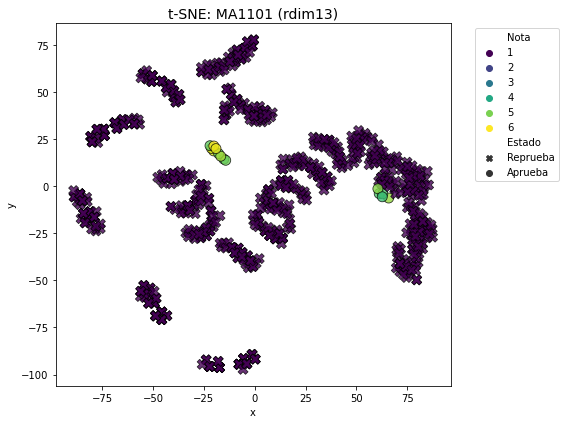


🔹 Generando gráfico para: MA1001


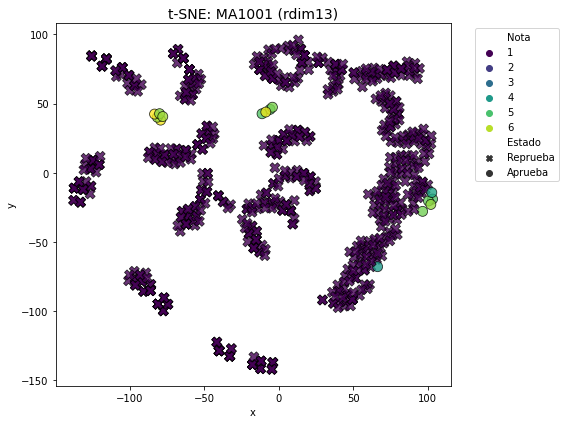


🔹 Generando gráfico para: FI1000


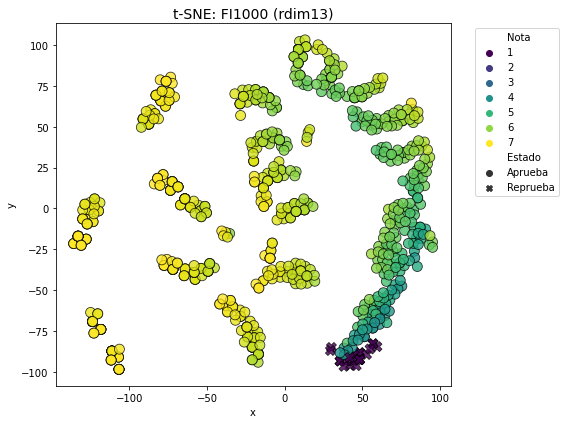


🔹 Generando gráfico para: BT1211


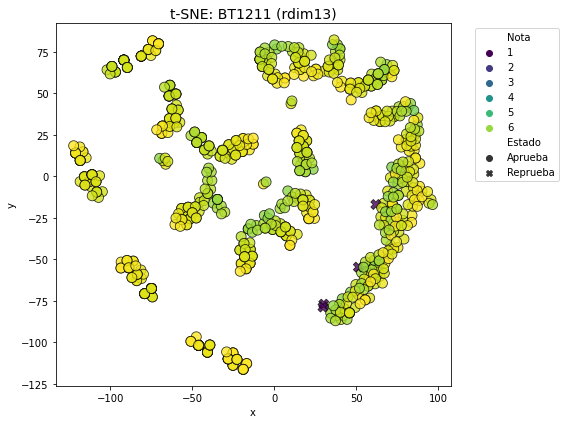


🔹 Generando gráfico para: MA1002


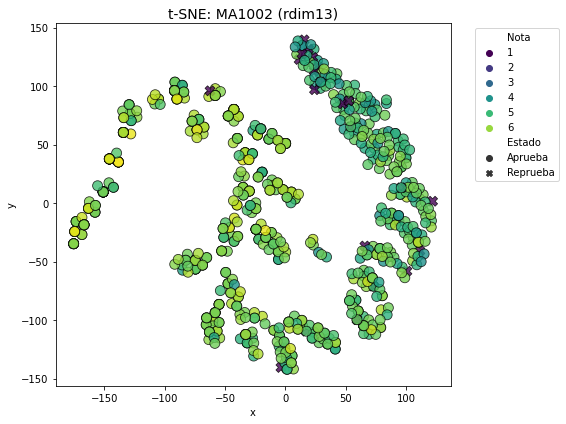


🔹 Generando gráfico para: MA1102


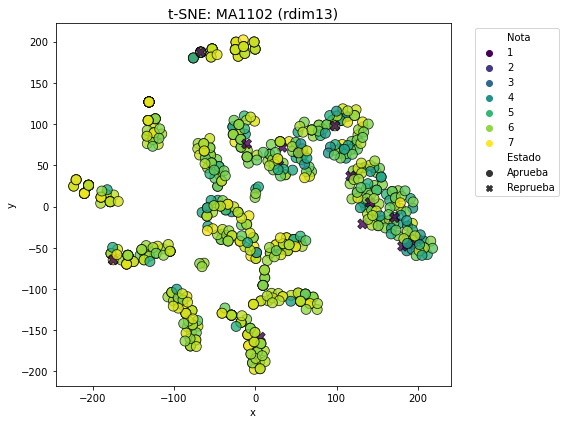


🔹 Generando gráfico para: FI1100


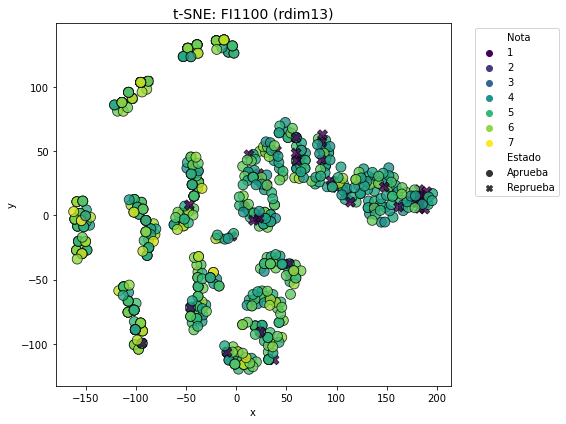


🔹 Generando gráfico para: CC1002


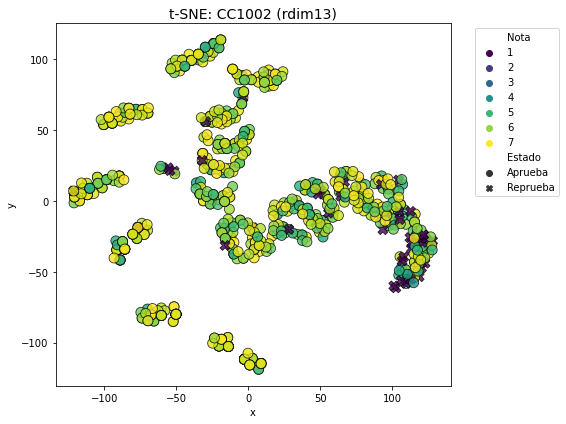


✅ Visualización finalizada.


In [1]:
# -*- coding: utf-8 -*-
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from types import SimpleNamespace

# =====================================
# CONFIGURACIÓN
# =====================================
RDIM = 13  # Modelo seleccionado

# Rutas
BASE_PATH = r"C:\Users\56946\TuckER\mis_scripts\dataframes_por_semestre"
RESULTS_BASE = r"C:\Users\56946\TuckER\results"
TUCKER_DATA_DIR = r"C:\Users\56946\TuckER\data\dataset_20192_fundamentales"
PREDICTOR_BASE = r"C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados"

# Nombres de archivos
RUN_PREFIX   = f"Experimento_warm_start_rdim{RDIM}_1000epochs_earlystopping_2019patience400_balanceado"
PREDICTOR_NAME = f"best_predictor_dim4_rdim{RDIM}_2019_balanceado.pt"

# Datos 2020
CSV_HISTORIA = os.path.join(BASE_PATH, "df_20201.csv")
CSV_TARGET   = os.path.join(BASE_PATH, "df_20202.csv")

# ⚠️ LISTA COMPLETA DE CURSOS A VISUALIZAR
CURSOS_PRIMER  = ['MA1101','MA1001','FI1000','BT1211']
CURSOS_SEGUNDO = ['MA1002','MA1102','FI1100','CC1002']
CURSOS_A_GRAFICAR = CURSOS_PRIMER + CURSOS_SEGUNDO

DEVICE = "cpu"

# =====================================
# FUNCIONES
# =====================================

def get_vocab_manual(data_dir):
    entities, relations = set(), set()
    nombres = ['train.txt', 'train_balanceado.txt', 'valid.txt', 'test.txt']
    for part in nombres:
        path = os.path.join(data_dir, part)
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    if not line.strip(): continue
                    h, r, t = line.strip().split()
                    entities.add(h.strip().upper()); entities.add(t.strip().upper()); relations.add(r.strip())
    entities = sorted(list(entities))
    return SimpleNamespace(entities=entities, entity_idxs={e: i for i, e in enumerate(entities)})

def load_tucker_weights(path, device="cpu"):
    sd = torch.load(path, map_location=device)
    if "model_state_dict" in sd: sd = sd["model_state_dict"]
    return sd["E.weight"].to(device), sd["W"].to(device)

class EmbeddingPredictor(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, output_size)
        )
    def forward(self, x): return self.network(x)

def limpiar_nota(nota_str, estado):
    if isinstance(estado, str) and "Reprobado" in estado: return 1.0
    try: return float(str(nota_str).replace(",", ".")) if not pd.isna(nota_str) else 0.0
    except: return 0.0

def precalcular_vectores_sem1(alumnos_ids, df_historia, idx_primer):
    vectores_np = {aid: np.zeros(4, dtype=np.float32) for aid in alumnos_ids}
    df_f = df_historia[df_historia["ID"].isin(alumnos_ids)]
    for _, row in df_f.iterrows():
        if row["CURSO"] in idx_primer:
            vectores_np[row["ID"]][idx_primer[row["CURSO"]]] = limpiar_nota(row["NOTA"], row["ESTADO_CURSO"])
    return {aid: torch.tensor(vec/7.0).view(1, -1) for aid, vec in vectores_np.items()}

def calcular_perfil_relacional(W, e_s, e_o):
    # W x_2 e_s x_3 e_o -> Vector de relación [dr]
    temp = torch.tensordot(W, e_s, dims=([1], [0]))
    v_perfil = torch.tensordot(temp, e_o, dims=([1], [0]))
    return v_perfil.cpu().numpy()

def main():
    print(f"--- 🎨 Visualizando t-SNE en Notebook (Rdim {RDIM}) ---")
    
    # 1. Cargar Modelos
    vocab = get_vocab_manual(TUCKER_DATA_DIR)
    tucker_path = os.path.join(RESULTS_BASE, RUN_PREFIX.format(rdim=RDIM), "best_model.pt")
    pred_path = os.path.join(PREDICTOR_BASE, PREDICTOR_NAME.format(rdim=RDIM))
    
    if not os.path.exists(tucker_path) or not os.path.exists(pred_path):
        print("❌ Archivos no encontrados.")
        return

    E, W = load_tucker_weights(tucker_path, DEVICE)
    d_e = E.shape[1]
    
    predictor = EmbeddingPredictor(4, d_e).to(DEVICE)
    predictor.load_state_dict(torch.load(pred_path, map_location=DEVICE))
    predictor.eval()

    # 2. Cargar Datos
    print("Cargando datos...")
    df_hist = pd.read_csv(CSV_HISTORIA, sep=';')
    df_tgt  = pd.read_csv(CSV_TARGET, sep=';')
    for df in [df_hist, df_tgt]:
        df['ID'] = df['ID'].astype(str).str.strip().str.upper()
        df['CURSO'] = df['CURSO'].astype(str).str.strip().str.upper()

    # Cohorte
    df_fund = df_hist[df_hist["CURSO"].isin(CURSOS_PRIMER)]
    conteo = df_fund.groupby("ID")["CURSO"].nunique()
    alumnos_validos = set(conteo[conteo == 4].index)
    
    # Precalcular
    idx_primer = {c: i for i, c in enumerate(CURSOS_PRIMER)}
    vectores_x = precalcular_vectores_sem1(alumnos_validos, df_hist, idx_primer)
    
    # 3. Bucle por Cursos
    for curso_obj in CURSOS_A_GRAFICAR:
        print(f"\n🔹 Generando gráfico para: {curso_obj}")
        
        if curso_obj not in vocab.entity_idxs:
            print(f"   ⚠️ Curso no encontrado en vocabulario.")
            continue
            
        idx_curso = vocab.entity_idxs[curso_obj]
        e_curso = E[idx_curso]

        # Seleccionar DataFrame correcto
        df_curso_data = df_hist if curso_obj in CURSOS_PRIMER else df_tgt
            
        df_registros = df_curso_data[
            (df_curso_data['CURSO'] == curso_obj) & 
            (df_curso_data['ID'].isin(alumnos_validos))
        ].copy()
        
        if len(df_registros) < 10:
            print(f"   ⚠️ Pocos datos ({len(df_registros)}). Saltando.")
            continue

        vectores_tsne = []
        notas = []
        estados = []
        
        with torch.no_grad():
            for _, row in df_registros.iterrows():
                aid = row['ID']
                if aid not in vectores_x: continue
                
                # Embedding
                x_vec = vectores_x[aid].to(DEVICE)
                e_alumno = predictor(x_vec).squeeze(0)
                
                # Perfil
                v_perfil = calcular_perfil_relacional(W, e_alumno, e_curso)
                vectores_tsne.append(v_perfil)
                
                # Nota y Estado
                estado = str(row['ESTADO_CURSO'])
                nota_raw = row['NOTA']
                
                nota_final = 1.0 # Default
                try: 
                    if not pd.isna(nota_raw):
                        nota_final = float(str(nota_raw).replace(",", "."))
                except: pass
                
                # Forzar 1.0 si es reprobado sin nota válida para que se vea rojo/azul
                if ("Reprobado" in estado or nota_final < 4.0) and nota_final == 0.0:
                    nota_final = 1.0
                
                notas.append(nota_final)
                estados.append("Reprueba" if "Reprobado" in estado or nota_final < 4.0 else "Aprueba")

        # t-SNE
        X = np.array(vectores_tsne, dtype=np.float32)
        perp = min(30, len(X)-1) if len(X) > 1 else 1
        
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=perp, init='pca', learning_rate=200.0)
            X_embedded = tsne.fit_transform(X)
            
            # Plot
            df_plot = pd.DataFrame({
                'x': X_embedded[:, 0],
                'y': X_embedded[:, 1],
                'Nota': notas,
                'Estado': estados
            })
            
            plt.figure(figsize=(8, 6))
            
            # Scatterplot Continuo
            sns.scatterplot(
                data=df_plot, x='x', y='y', 
                hue='Nota', palette='viridis', 
                style='Estado', markers={'Aprueba': 'o', 'Reprueba': 'X'},
                s=100, alpha=0.8, edgecolor='k'
            )
            
            plt.title(f"t-SNE: {curso_obj} (rdim{RDIM})", fontsize=14)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show() # <--- MUESTRA EN NOTEBOOK
            
        except Exception as e:
            print(f"   ❌ Error t-SNE: {e}")

    print("\n✅ Visualización finalizada.")

if __name__ == "__main__":
    main()

--- 🎨 Visualizando t-SNE Híbrido (Capas Separadas) ---
Cargando datos...

🔹 Generando gráfico para: MA1101


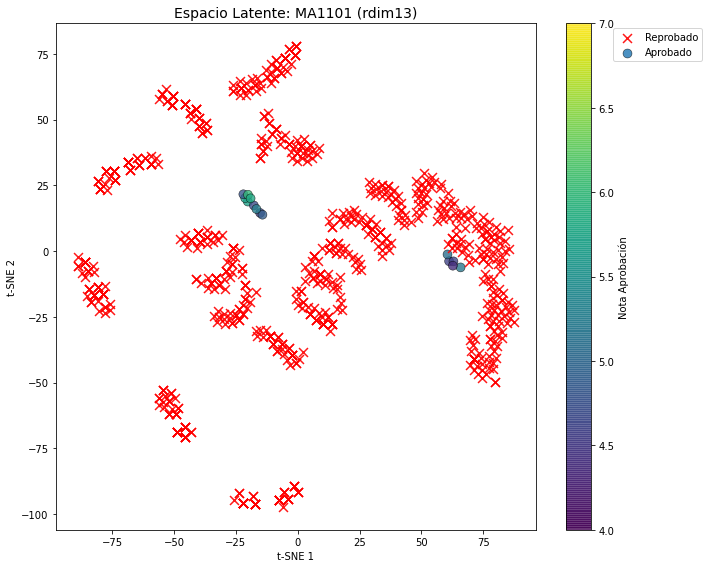


🔹 Generando gráfico para: MA1001


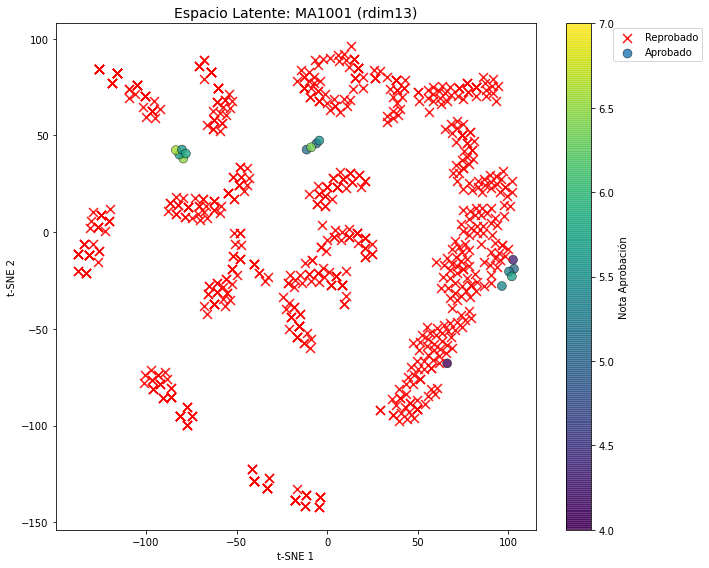


🔹 Generando gráfico para: FI1000


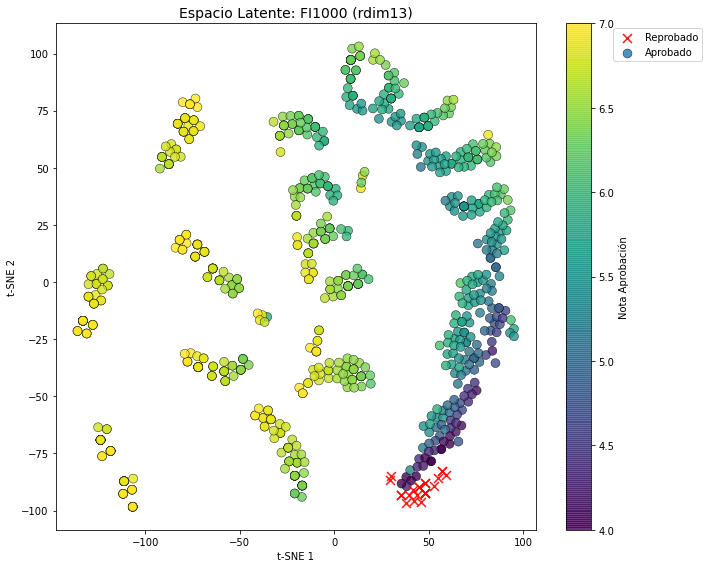


🔹 Generando gráfico para: BT1211


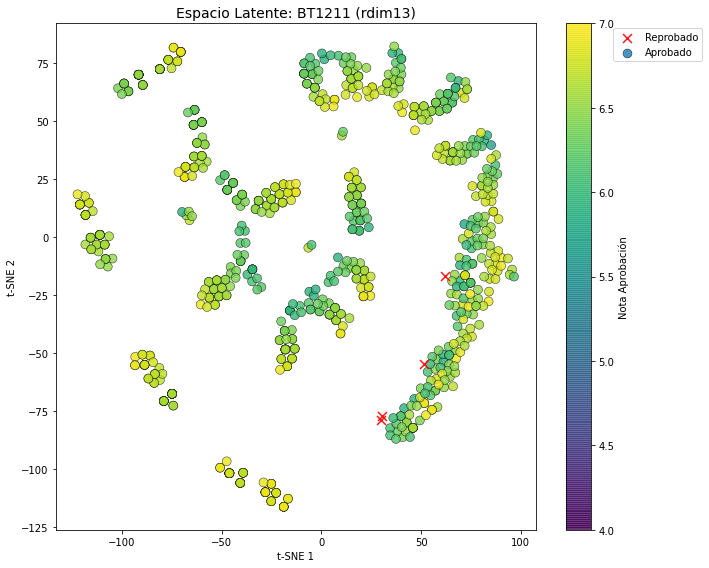


🔹 Generando gráfico para: MA1002


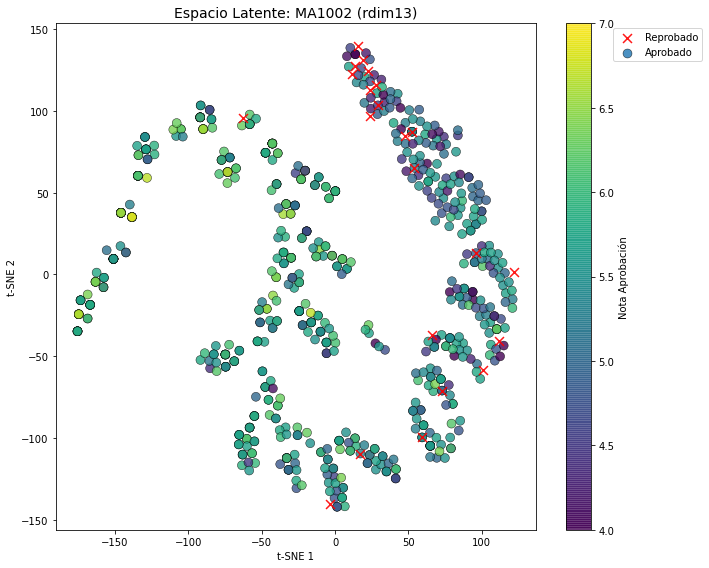


🔹 Generando gráfico para: MA1102


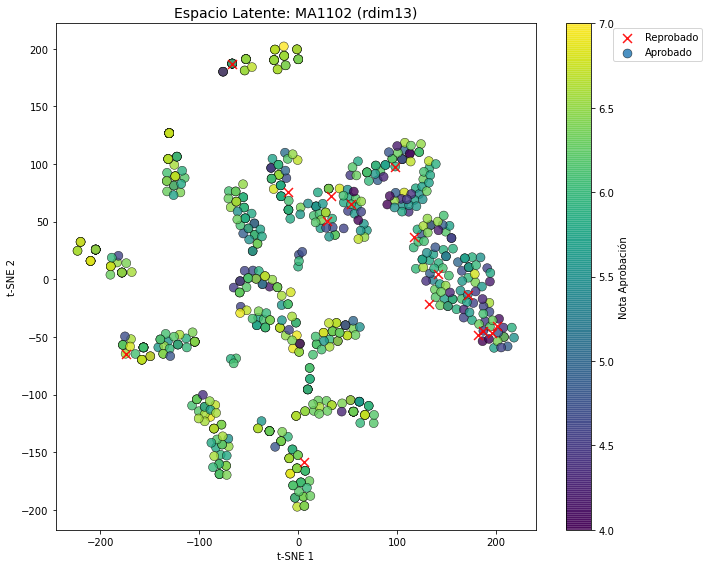


🔹 Generando gráfico para: FI1100


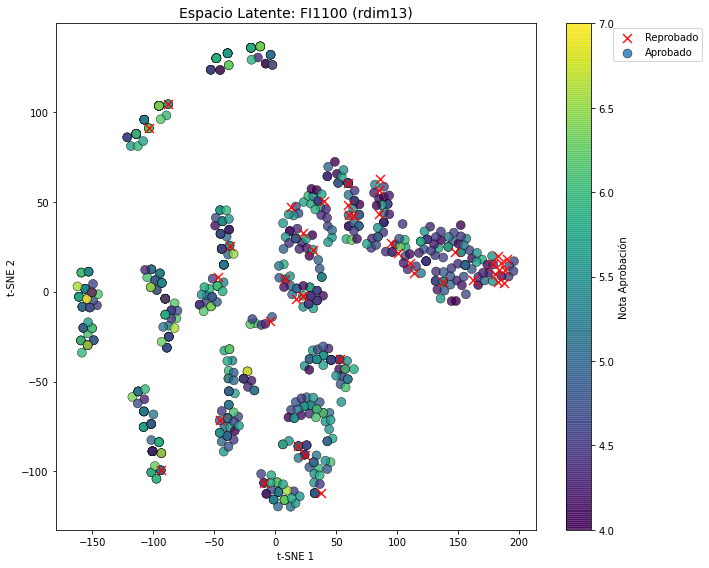


🔹 Generando gráfico para: CC1002


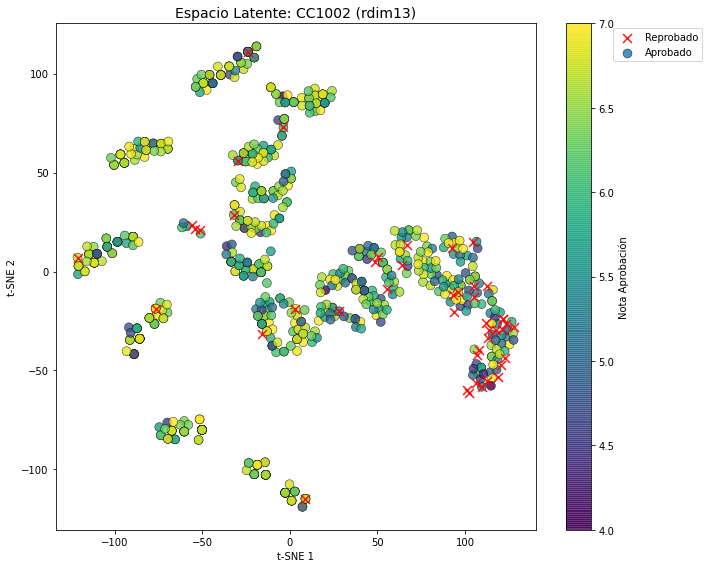


✅ Visualización finalizada.


In [2]:
# -*- coding: utf-8 -*-
import os, sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from types import SimpleNamespace

# =====================================
# CONFIGURACIÓN
# =====================================
RDIM = 13  # Modelo seleccionado

# Rutas
BASE_PATH = r"C:\Users\56946\TuckER\mis_scripts\dataframes_por_semestre"
RESULTS_BASE = r"C:\Users\56946\TuckER\results"
TUCKER_DATA_DIR = r"C:\Users\56946\TuckER\data\dataset_20192_fundamentales"
PREDICTOR_BASE = r"C:\Users\56946\TuckER\notebooks\Experimento_warm_start\predictores_sem1_balanceados"

# Nombres de archivos
RUN_PREFIX   = f"Experimento_warm_start_rdim{RDIM}_1000epochs_earlystopping_2019patience400_balanceado"
PREDICTOR_NAME = f"best_predictor_dim4_rdim{RDIM}_2019_balanceado.pt"

# Datos 2020
CSV_HISTORIA = os.path.join(BASE_PATH, "df_20201.csv")
CSV_TARGET   = os.path.join(BASE_PATH, "df_20202.csv")

# ⚠️ LISTA COMPLETA DE CURSOS A VISUALIZAR
CURSOS_PRIMER  = ['MA1101','MA1001','FI1000','BT1211']
CURSOS_SEGUNDO = ['MA1002','MA1102','FI1100','CC1002']
CURSOS_A_GRAFICAR = CURSOS_PRIMER + CURSOS_SEGUNDO

DEVICE = "cpu"

# =====================================
# FUNCIONES
# =====================================

def get_vocab_manual(data_dir):
    entities, relations = set(), set()
    nombres = ['train.txt', 'train_balanceado.txt', 'valid.txt', 'test.txt']
    for part in nombres:
        path = os.path.join(data_dir, part)
        if os.path.exists(path):
            with open(path, 'r', encoding='utf-8') as f:
                for line in f:
                    if not line.strip(): continue
                    h, r, t = line.strip().split()
                    entities.add(h.strip().upper()); entities.add(t.strip().upper()); relations.add(r.strip())
    entities = sorted(list(entities))
    return SimpleNamespace(entities=entities, entity_idxs={e: i for i, e in enumerate(entities)})

def load_tucker_weights(path, device="cpu"):
    sd = torch.load(path, map_location=device)
    if "model_state_dict" in sd: sd = sd["model_state_dict"]
    return sd["E.weight"].to(device), sd["W"].to(device)

class EmbeddingPredictor(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, output_size)
        )
    def forward(self, x): return self.network(x)

def limpiar_nota(nota_str, estado):
    if isinstance(estado, str) and "Reprobado" in estado: return 1.0
    try: return float(str(nota_str).replace(",", ".")) if not pd.isna(nota_str) else 0.0
    except: return 0.0

def precalcular_vectores_sem1(alumnos_ids, df_historia, idx_primer):
    vectores_np = {aid: np.zeros(4, dtype=np.float32) for aid in alumnos_ids}
    df_f = df_historia[df_historia["ID"].isin(alumnos_ids)]
    for _, row in df_f.iterrows():
        if row["CURSO"] in idx_primer:
            vectores_np[row["ID"]][idx_primer[row["CURSO"]]] = limpiar_nota(row["NOTA"], row["ESTADO_CURSO"])
    return {aid: torch.tensor(vec/7.0).view(1, -1) for aid, vec in vectores_np.items()}

def calcular_perfil_relacional(W, e_s, e_o):
    temp = torch.tensordot(W, e_s, dims=([1], [0]))
    v_perfil = torch.tensordot(temp, e_o, dims=([1], [0]))
    return v_perfil.cpu().numpy()

def main():
    print(f"--- 🎨 Visualizando t-SNE Híbrido (Capas Separadas) ---")
    
    # 1. Cargar Modelos
    vocab = get_vocab_manual(TUCKER_DATA_DIR)
    tucker_path = os.path.join(RESULTS_BASE, RUN_PREFIX.format(rdim=RDIM), "best_model.pt")
    pred_path = os.path.join(PREDICTOR_BASE, PREDICTOR_NAME.format(rdim=RDIM))
    
    if not os.path.exists(tucker_path) or not os.path.exists(pred_path):
        print("❌ Archivos no encontrados.")
        return

    E, W = load_tucker_weights(tucker_path, DEVICE)
    d_e = E.shape[1]
    
    predictor = EmbeddingPredictor(4, d_e).to(DEVICE)
    predictor.load_state_dict(torch.load(pred_path, map_location=DEVICE))
    predictor.eval()

    # 2. Cargar Datos
    print("Cargando datos...")
    df_hist = pd.read_csv(CSV_HISTORIA, sep=';')
    df_tgt  = pd.read_csv(CSV_TARGET, sep=';')
    for df in [df_hist, df_tgt]:
        df['ID'] = df['ID'].astype(str).str.strip().str.upper()
        df['CURSO'] = df['CURSO'].astype(str).str.strip().str.upper()

    # Cohorte
    df_fund = df_hist[df_hist["CURSO"].isin(CURSOS_PRIMER)]
    conteo = df_fund.groupby("ID")["CURSO"].nunique()
    alumnos_validos = set(conteo[conteo == 4].index)
    
    # Precalcular
    idx_primer = {c: i for i, c in enumerate(CURSOS_PRIMER)}
    vectores_x = precalcular_vectores_sem1(alumnos_validos, df_hist, idx_primer)
    
    # 3. Bucle por Cursos
    for curso_obj in CURSOS_A_GRAFICAR:
        print(f"\n🔹 Generando gráfico para: {curso_obj}")
        
        if curso_obj not in vocab.entity_idxs:
            print(f"   ⚠️ Curso no encontrado en vocabulario.")
            continue
            
        idx_curso = vocab.entity_idxs[curso_obj]
        e_curso = E[idx_curso]

        df_curso_data = df_hist if curso_obj in CURSOS_PRIMER else df_tgt
            
        df_registros = df_curso_data[
            (df_curso_data['CURSO'] == curso_obj) & 
            (df_curso_data['ID'].isin(alumnos_validos))
        ].copy()
        
        if len(df_registros) < 10:
            print(f"   ⚠️ Pocos datos ({len(df_registros)}). Saltando.")
            continue

        vectores_tsne = []
        notas_reales = []
        es_reprobado_list = []
        
        with torch.no_grad():
            for _, row in df_registros.iterrows():
                aid = row['ID']
                if aid not in vectores_x: continue
                
                # Embedding
                x_vec = vectores_x[aid].to(DEVICE)
                e_alumno = predictor(x_vec).squeeze(0)
                
                # Perfil
                v_perfil = calcular_perfil_relacional(W, e_alumno, e_curso)
                vectores_tsne.append(v_perfil)
                
                # Lógica de Nota y Estado
                estado = str(row['ESTADO_CURSO'])
                nota_raw = row['NOTA']
                
                nota_final = 0.0 # Default si no hay nota
                try: 
                    if not pd.isna(nota_raw):
                        nota_final = float(str(nota_raw).replace(",", "."))
                except: pass
                
                es_rep = ("Reprobado" in estado or nota_final < 4.0)
                
                es_reprobado_list.append(es_rep)
                notas_reales.append(nota_final)

        # t-SNE
        X = np.array(vectores_tsne, dtype=np.float32)
        perp = min(30, len(X)-1) if len(X) > 1 else 1
        
        try:
            tsne = TSNE(n_components=2, random_state=42, perplexity=perp, init='pca', learning_rate=200.0)
            X_embedded = tsne.fit_transform(X)
            
            # DataFrame para Plotting
            df_plot = pd.DataFrame({
                'x': X_embedded[:, 0],
                'y': X_embedded[:, 1],
                'Nota': notas_reales,
                'Es_Reprobado': es_reprobado_list
            })
            
            # Separar grupos
            df_repro = df_plot[df_plot['Es_Reprobado'] == True]
            df_aprob = df_plot[df_plot['Es_Reprobado'] == False]
            
            plt.figure(figsize=(10, 8))
            
            # 1. Capa Reprobados (Color fijo: Rojo, Marca: X)
            if not df_repro.empty:
                plt.scatter(
                    df_repro['x'], df_repro['y'],
                    c='red', marker='x', s=80, 
                    label='Reprobado', alpha=0.9, zorder=2
                )
            
            # 2. Capa Aprobados (Mapa de calor Viridis: 4.0 a 7.0)
            if not df_aprob.empty:
                sc = plt.scatter(
                    df_aprob['x'], df_aprob['y'],
                    c=df_aprob['Nota'], cmap='viridis',
                    marker='o', s=80, alpha=0.8, edgecolors='k', linewidth=0.5,
                    vmin=4.0, vmax=7.0, # ⚠️ FORZAR ESCALA 4-7
                    label='Aprobado', zorder=1
                )
                # Barra de color solo para aprobados
                cbar = plt.colorbar(sc)
                cbar.set_label('Nota Aprobación')
            
            plt.title(f"Espacio Latente: {curso_obj} (rdim{RDIM})", fontsize=14)
            plt.xlabel("t-SNE 1")
            plt.ylabel("t-SNE 2")
            plt.legend(loc='upper left', bbox_to_anchor=(1.15, 1)) # Leyenda afuera para no tapar
            plt.tight_layout()
            plt.show() # Muestra en notebook
            
        except Exception as e:
            print(f"   ❌ Error t-SNE: {e}")

    print("\n✅ Visualización finalizada.")

if __name__ == "__main__":
    main()